In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv("../Data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
#First 5 Rows
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
#Dataset Shape
df.shape

(1470, 35)

In [5]:
#Columns Check
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
#Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
#Missing Values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Business Question

In [8]:
#Attrition Count
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
#Attrition Percentage
attrition_rate = (df['Attrition'].value_counts(normalize=True) * 100)

attrition_rate

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

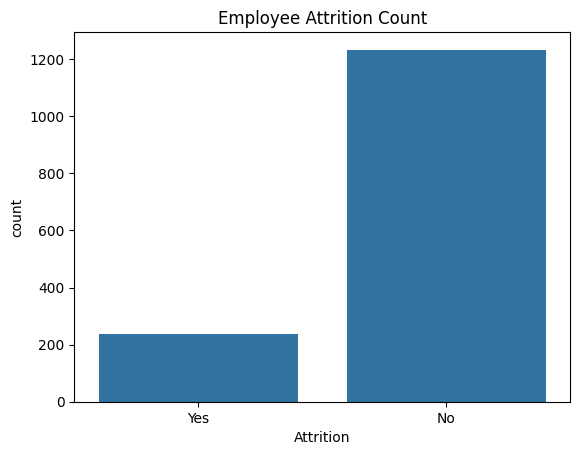

In [10]:
#Attrition Visualization
sns.countplot(x='Attrition', data=df)

plt.title("Employee Attrition Count")

plt.show()

In [11]:
#Insights
#majority employees company me stay kar rahe hain
#attrition controlled hai 👍

In [12]:
#Department-wise Attrition
pd.crosstab(df['Department'], df['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


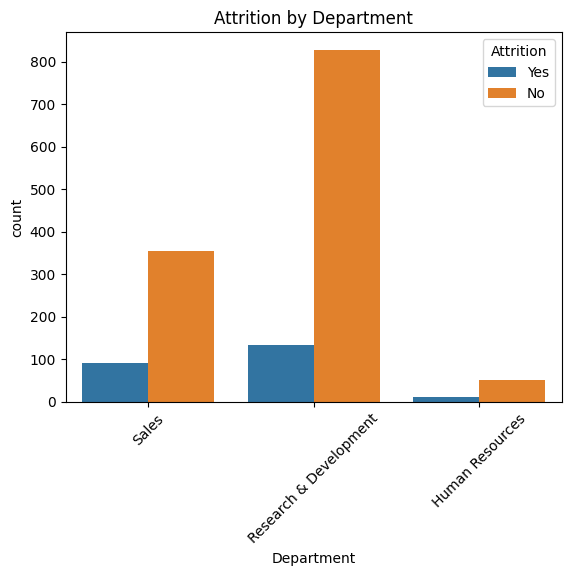

In [13]:
#Visualization
sns.countplot(x='Department', hue='Attrition', data=df)

plt.title("Attrition by Department")

plt.xticks(rotation=45)

plt.show()

In [14]:
#Insight
#Research & Development department me sabse zyada attrition ho raha hai 

#Sales second hai.

#HR lowest attrition.

In [15]:
#Salary vs Attrition


In [16]:
#Average Salary by Attrition
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

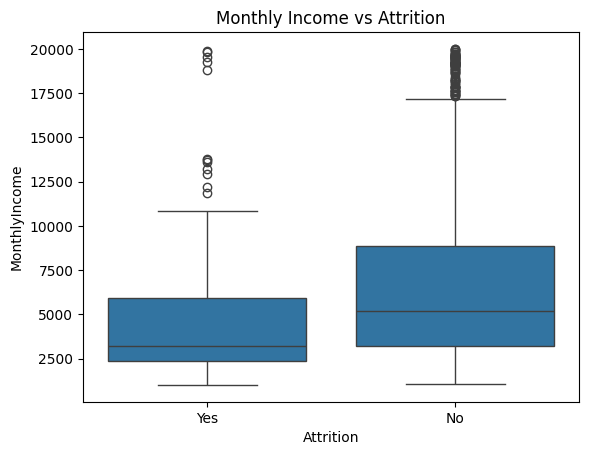

In [17]:
#Visualization
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.title("Monthly Income vs Attrition")

plt.show()

#Hum check karenge:

#low salary employees company zyada chhod rahe hain ya nahi

In [18]:
#Low salary employees
#zyada company leave kar rahe hain.
#Higher salary employees mostly stay kar rahe hain.

#Business Insight:
#Better compensation employee retention improve kar sakta hai.

In [19]:
#Overtime vs Attrition
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


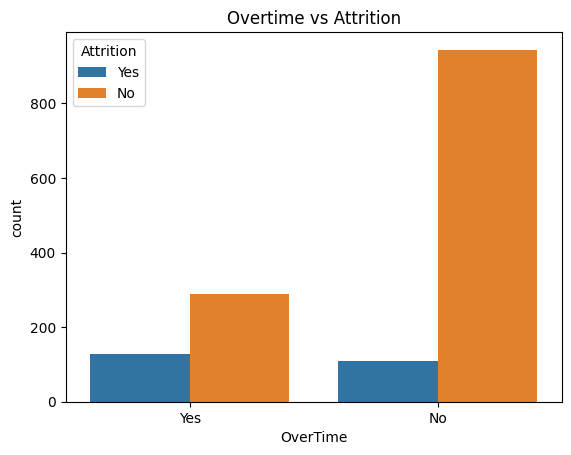

In [20]:
#Visualization
sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title("Overtime vs Attrition")

plt.show()

#Usually:
#overtime employees
#zyada resign karte hain.

In [21]:
#Employees doing overtimehave significantly higher attrition.
#Overwork → burnout → resignation.

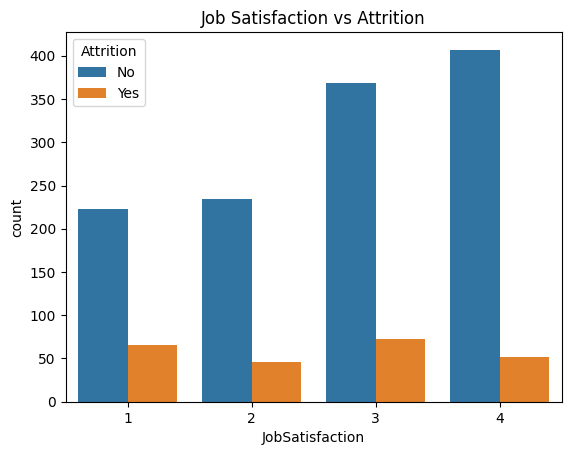

In [22]:
#Job Satisfaction
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)

plt.title("Job Satisfaction vs Attrition")

plt.show()
#low satisfaction employees resign kar rahe hain ya nahi.

In [23]:
#Low satisfaction levels (1 & 2) me attrition relatively higher hai.
#High satisfaction employees zyada stable hain.

In [24]:
#Business Insight:
#Employee engagement aur work culture improve karna important hai.